## 주가 데이터

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
# 애플 주가 데이터 다운로드
ticker = 'AAPL'
start_date = '2024-01-01'
end_date = '2024-10-01'
aapl_df = yf.download('AAPL', start_date, end_date, multi_level_index=False, auto_adjust=False)
aapl_df.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-01-02,187.149994,188.440002,183.889999,185.639999,184.734985,82488700
2024-01-03,184.220001,185.880005,183.429993,184.250000,183.351761,58414500
2024-01-04,182.149994,183.089996,180.880005,181.910004,181.023178,71983600
2024-01-05,181.990005,182.759995,180.169998,181.179993,180.296707,62303300
2024-01-08,182.089996,185.600006,181.500000,185.559998,184.655365,59144500


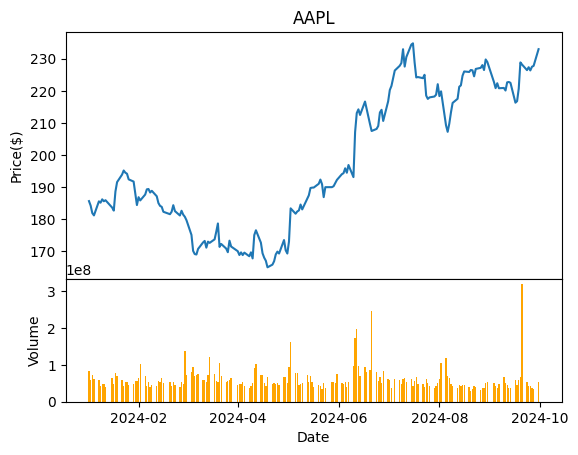

In [3]:
# 애플 종가와 거래량 그래프
import matplotlib.dates as mdates

fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=(2,1))

ax[0].plot(aapl_df.index, aapl_df.Close)
ax[1].bar(aapl_df.index, aapl_df.Volume, color='orange')

ax[0].set_title('AAPL')
ax[0].set_ylabel('Price($)')

ax[1].set_xlabel('Date')
ax[1].set_ylabel('Volume')
ax[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.subplots_adjust(hspace=0)
# plt.savefig('plt_06.png', dpi=300)
plt.show()

## 재무제표 정보

In [4]:
# 애플 재무데이터 다운로드
# 기업 정보 다운드드
aapl = yf.Ticker('AAPL')
aapl_info = aapl.info

# 재무지표 출력
print(f"PER: {aapl_info['trailingPE']}")
print(f"EPS: {aapl_info['trailingEps']}")
print(f"PBR: {aapl_info['priceToBook']}")
print(f"ROE: {aapl_info['priceToBook']/aapl_info['trailingPE']:3f}")
print(f"PEG: {aapl_info['trailingPegRatio']}")

PER: 37.88797
EPS: 6.07
PBR: 61.051235
ROE: 1.611362
PEG: 2.0958


## 일간 수익률 분석

[*********************100%%**********************]  1 of 1 completed


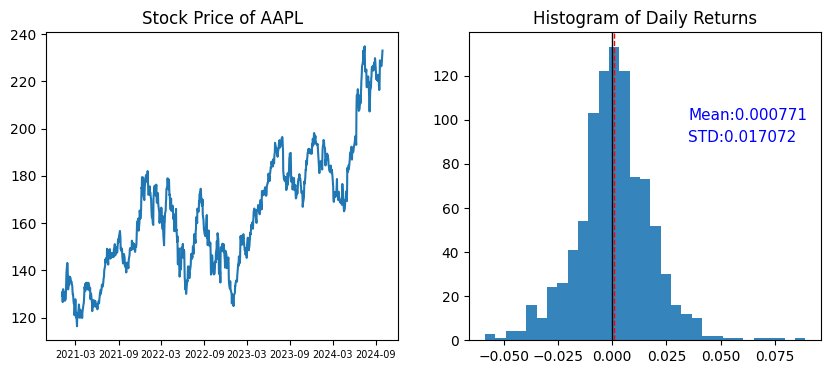

In [5]:
# 주가 데이터 다운로드
ticker = 'AAPL'
start_date = '2021-01-01'
end_date = '2024-10-01'
aapl_df = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

# 일간 수익률과 평균, 분산 계산
daily_returns =  aapl_df['Close'].pct_change().dropna()
ret_mean = daily_returns.mean()
ret_std = daily_returns.std()

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(aapl_df.index, aapl_df.Close)
ax[0].set_title('Stock Price of AAPL')
ax[0].tick_params(axis='x', labelsize=7) 
ax[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

ax[1].hist( daily_returns.values, bins=31, alpha=0.9)
ax[1].axvline(x=0, color='black', linewidth=1)
ax[1].axvline(x=ret_mean, color='red', linewidth=1, linestyle='--')
ax[1].text(0.035, 100, f'Mean:{ret_mean:6f}', color='blue', fontsize=11)
ax[1].text(0.035, 90, f'STD:{ret_std:4f}', color='blue', fontsize=11)
ax[1].set_title('Histogram of Daily Returns')

# plt.savefig('plt_07.png', dpi=300)
plt.show()

In [6]:
# 애플 주가 일간 수익률 회귀 분석
import statsmodels.api as sm

yesterday_returns = daily_returns.shift().dropna()
today_returns = daily_returns.iloc[1:].copy()

X = yesterday_returns.values
Y = today_returns.values
X_const = sm.add_constant(X)
model = sm.OLS(Y,X_const).fit()
print(f'R_squared: {model.rsquared:.3f}')

R_squared: 0.000


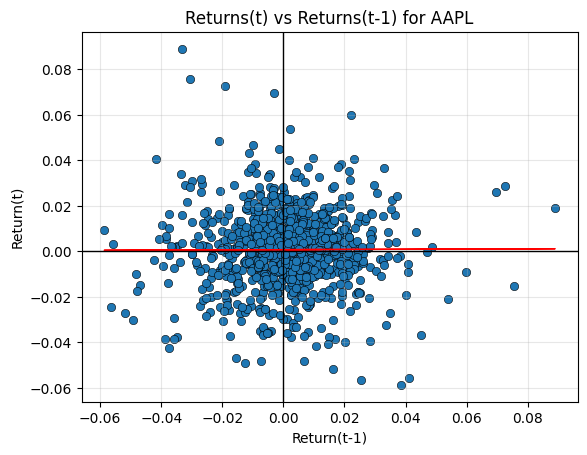

In [7]:
# 애플 주가 일간 수익률 산점도
Y_pred = model.predict(X_const)

plt.scatter(X, Y, edgecolors='black', linewidths=0.4)
plt.plot(X, Y_pred, color='red', linewidth=1)
plt.axhline(y=0, color='black', linewidth=1)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Returns(t) vs Returns(t-1) for AAPL')
plt.xlabel('Return(t-1)')
plt.ylabel('Return(t)')
plt.grid(alpha=0.3)
# plt.savefig('plt_08.png', dpi=300)
plt.show()

## 이동평균 계산

[*********************100%%**********************]  1 of 1 completed


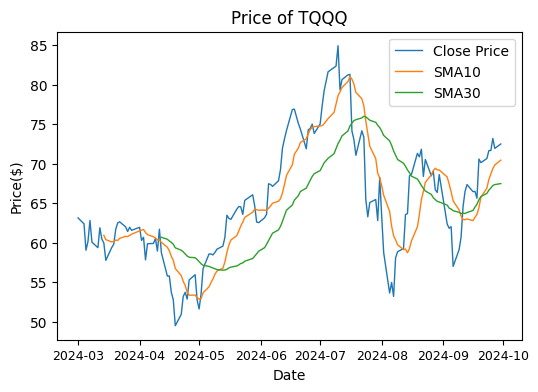

In [8]:
# TQQQ 단순이동평균선 구하기

# 주가 데이터 다운로드
ticker = 'TQQQ'
start_date = '2024-03-01'
end_date = '2024-10-01'
tqqq = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

# 단순이동평균 계산
tqqq['sma10'] = tqqq['Close'].rolling(window=10, min_periods=10).mean()
tqqq['sma30'] = tqqq['Close'].rolling(window=30, min_periods=30).mean()

# 시각화
plt.figure(figsize=(6,4))

plt.plot(tqqq.Close, label='Close Price', linewidth=1)
plt.plot(tqqq.sma10, label='SMA10', linewidth=1)
plt.plot(tqqq.sma30, label='SMA30', linewidth=1)

plt.title('Price of TQQQ')
plt.xlabel('Date')
plt.ylabel('Price($)')
plt.tick_params(axis='x', labelsize=9)
plt.legend()
# plt.savefig('plt_09.png', dpi=300)
plt.show()

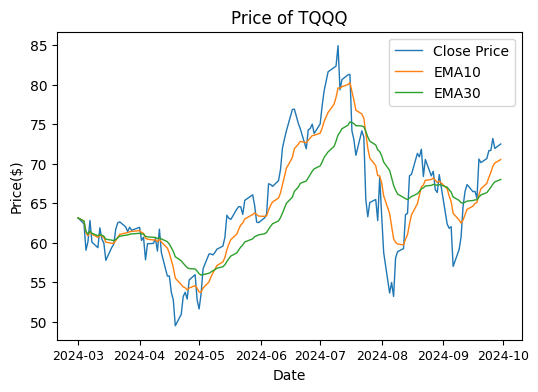

In [9]:
# TQQQ 지수가중이동평균선 구하기

# 지수가중이동평균 계산
tqqq['ema10'] = tqqq['Close'].ewm(span=10, adjust=True).mean()
tqqq['ema30'] = tqqq['Close'].ewm(span=30, adjust=True).mean()

# 시각화
plt.figure(figsize=(6,4))

plt.plot(tqqq.Close, label='Close Price', linewidth=1)
plt.plot(tqqq.ema10, label='EMA10', linewidth=1)
plt.plot(tqqq.ema30, label='EMA30', linewidth=1)

plt.title('Price of TQQQ')
plt.xlabel('Date')
plt.ylabel('Price($)')
plt.tick_params(axis='x', labelsize=9)
plt.legend()
# plt.savefig('plt_10.png', dpi=300)
plt.show()

## 기술적 지표 계산

In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

[*********************100%%**********************]  1 of 1 completed


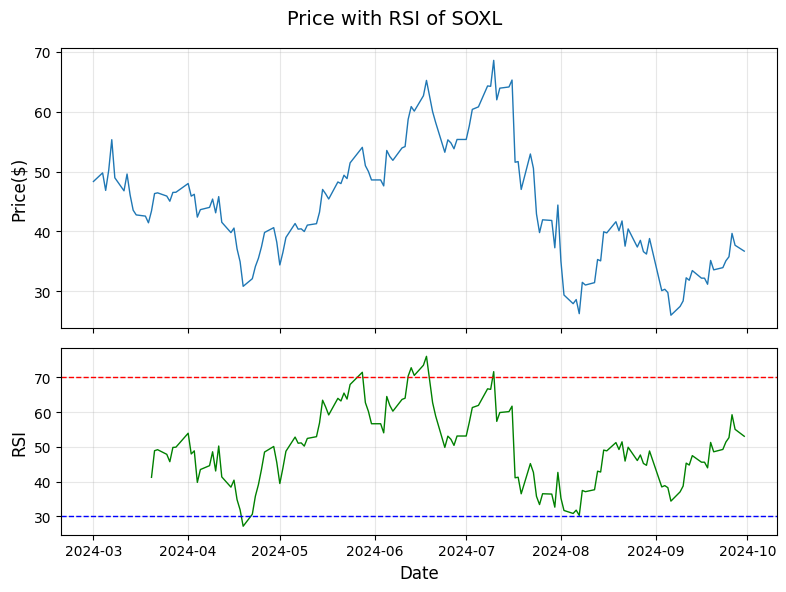

In [11]:
# RSI 계산

import ta

# 주가 데이터 다운로드
ticker = 'SOXL'
start_date = '2024-03-01'
end_date = '2024-10-01'
soxl = yf.download(ticker, start_date, end_date, multi_level_index=False, auto_adjust=False)

# RSI 계산
period = 14
soxl['RSI'] = ta.momentum.rsi(soxl.Close, window=period)

# 시각화
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=(3,2), figsize=(8,6))
ax[0].plot(soxl.Close, linewidth=1)
ax[0].grid(alpha=0.3)
ax[0].set_ylabel('Price($)', fontsize=12)

ax[1].plot(soxl.RSI, color='green', linewidth=1)
ax[1].axhline(y=30, color='blue', linewidth=1, linestyle='--')
ax[1].axhline(y=70, color='red', linewidth=1, linestyle='--')
ax[1].grid(alpha=0.3)
ax[1].set_xlabel('Date', fontsize=12)
ax[1].set_ylabel('RSI', fontsize=12)

fig.suptitle('Price with RSI of SOXL', fontsize=14)
plt.tight_layout()
# plt.savefig('plt_11.png', dpi=300)
plt.show()

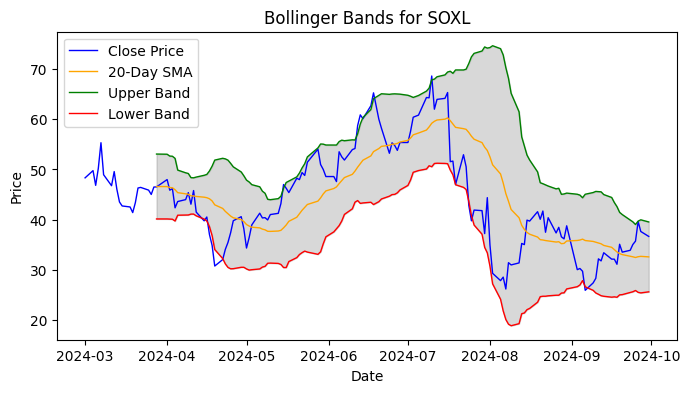

In [12]:
# 볼린저 밴드 계산

# 중심선과 표준편차 계산
soxl['SMA20'] = soxl['Close'].rolling(window=20).mean()
soxl['STD20'] = soxl['Close'].rolling(window=20).std()

# 상하단선 계산
soxl['Upper Band'] = soxl['SMA20'] + 2*soxl['STD20']
soxl['Lower Band'] = soxl['SMA20'] - 2*soxl['STD20']

# 시각화
plt.figure(figsize=(8,4))
plt.plot(soxl['Close'], label='Close Price', color='blue', linewidth=1)
plt.plot(soxl['SMA20'], label='20-Day SMA', color='orange', linewidth=1)
plt.plot(soxl['Upper Band'], label='Upper Band', color='green', linewidth=1)
plt.plot(soxl['Lower Band'], label='Lower Band', color='red', linewidth=1)

plt.fill_between(soxl.index, soxl['Upper Band'], soxl['Lower Band'], color='gray', alpha=0.3)

plt.title(f"Bollinger Bands for SOXL")
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.savefig('plt_12.png', dpi=300)
plt.show()